Load the Dataset

In [51]:
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [53]:
df.isnull().sum()

label    0
text     0
dtype: int64

Text Pre-processing 

NLTK Library: used to process and convert the human language data into the machine understandable data.

In [54]:
import re, nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return ' '.join(w for w in text.split() if w not in stop_words)

df['clean'] = df['text'].apply(clean)

print("\nOriginal:", df['text'][0])
print("Cleaned :", df['clean'][0])



Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned : go jurong point crazy available bugis n great world la e buffet cine got amore wat


[nltk_data] Downloading package stopwords to C:\Users\Janvi
[nltk_data]     Panchal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Bar chart

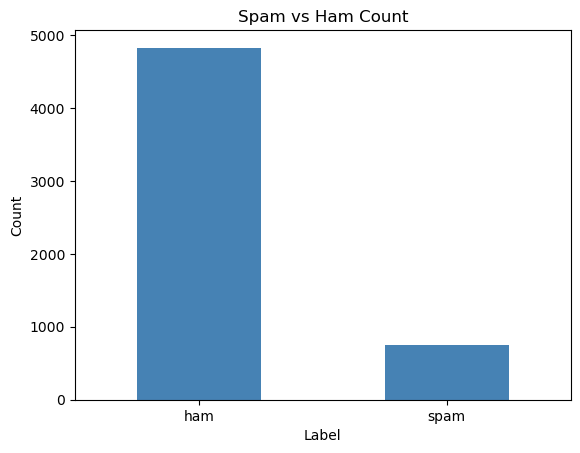

In [55]:
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'steelblue'])
plt.title('Spam vs Ham Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show() 

Insights : In the dataset most of the emails are ham . This reflects the fact that in our actual inbox most emails are ham and only small portion is spam .

Feature Engineering

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

Model Training

NAIVE BAYES

In [57]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_preds = nb.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_preds))


Accuracy: 0.9730941704035875
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
 [[965   0]
 [ 30 120]]


SVM - Supprt Vector Machine 

In [58]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)
svm_preds = svm.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, svm_preds))
print(classification_report(y_test, svm_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_preds))

Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.97      0.86      0.91       150

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
 [[961   4]
 [ 21 129]]


Unknow mail prediction

In [59]:
def predict_email(text, model, model_name):
    cleaned = clean(text)
    vectorized = vectorizer.transform([cleaned])
    result = model.predict(vectorized)[0]
    print(f"[{model_name}] → {result.upper()}")


test_emails = [
    "Congratulations! You've won a FREE iPhone.Click here to claim your reward.",
        "Please find attached the report for this week's progress update."
]

for email in test_emails:
    print(f"\nEmail: {email[:60]}...")
    predict_email(email, nb,  "Naive Bayes")
    predict_email(email, svm, "SVM")


Email: Congratulations! You've won a FREE iPhone.Click here to clai...
[Naive Bayes] → SPAM
[SVM] → SPAM

Email: Please find attached the report for this week's progress upd...
[Naive Bayes] → HAM
[SVM] → HAM


Best model Selection

In [60]:
results = {
    'Naive Bayes':         0.9730,
    'SVM':                 0.9775
}
best_model_name = max(results, key=results.get)

print(f"\nBest Model : {best_model_name}")
print(f"Accuracy   : {results[best_model_name]*100:.2f}%")
print(f"Reason     : Highest accuracy + best spam recall + best F1 ")
print(f"\n{best_model_name} is considered as a best model")


Best Model : SVM
Accuracy   : 97.75%
Reason     : Highest accuracy + best spam recall + best F1 

SVM is considered as a best model


In [61]:
import pickle

with open("spam_model.pkl", "wb") as file:
    pickle.dump(svm, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)